In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# iris is a dataset available in skelearn natively. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris

In [118]:
#Loading dataset
iris = load_iris()
X_full, Y_full = iris.data, iris.target

#Print the class names
class_names = iris.target_names
print("Class Names:")
for i, name in enumerate(class_names):
    print(f"Class {i}: {name}")

# Get the feature names
feature_names = iris.feature_names
print("Feature Names:")
for i, name in enumerate(feature_names):
    print(f"Feature {i}: {name}")

# Get the description of the dataset
description = iris.DESCR

# Print the description
print(description)

Class Names:
Class 0: setosa
Class 1: versicolor
Class 2: virginica
Feature Names:
Feature 0: sepal length (cm)
Feature 1: sepal width (cm)
Feature 2: petal length (cm)
Feature 3: petal width (cm)
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal w

In [119]:
# Convert the dataset to a pandas DataFrame for easy visualization
df = pd.DataFrame(X_full, columns=iris.feature_names)
df['Class'] = iris.target_names[Y_full]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [120]:
# Determine the unique class labels
unique_classes = np.unique(Y_full)

# Define how many samples to print per class
samples_per_class = 2

# Print samples from each class
for cls in unique_classes:
    print(f"Class {cls} - {iris.target_names[cls]}:")
    class_indices = np.where(Y_full == cls)[0]
    for i, idx in enumerate(class_indices[:samples_per_class]):
        print(f"Sample {i + 1}:")
        print("Features:", X_full[idx])
        print("Label:", Y_full[idx])
        print()

Class 0 - setosa:
Sample 1:
Features: [5.1 3.5 1.4 0.2]
Label: 0

Sample 2:
Features: [4.9 3.  1.4 0.2]
Label: 0

Class 1 - versicolor:
Sample 1:
Features: [7.  3.2 4.7 1.4]
Label: 1

Sample 2:
Features: [6.4 3.2 4.5 1.5]
Label: 1

Class 2 - virginica:
Sample 1:
Features: [6.3 3.3 6.  2.5]
Label: 2

Sample 2:
Features: [5.8 2.7 5.1 1.9]
Label: 2



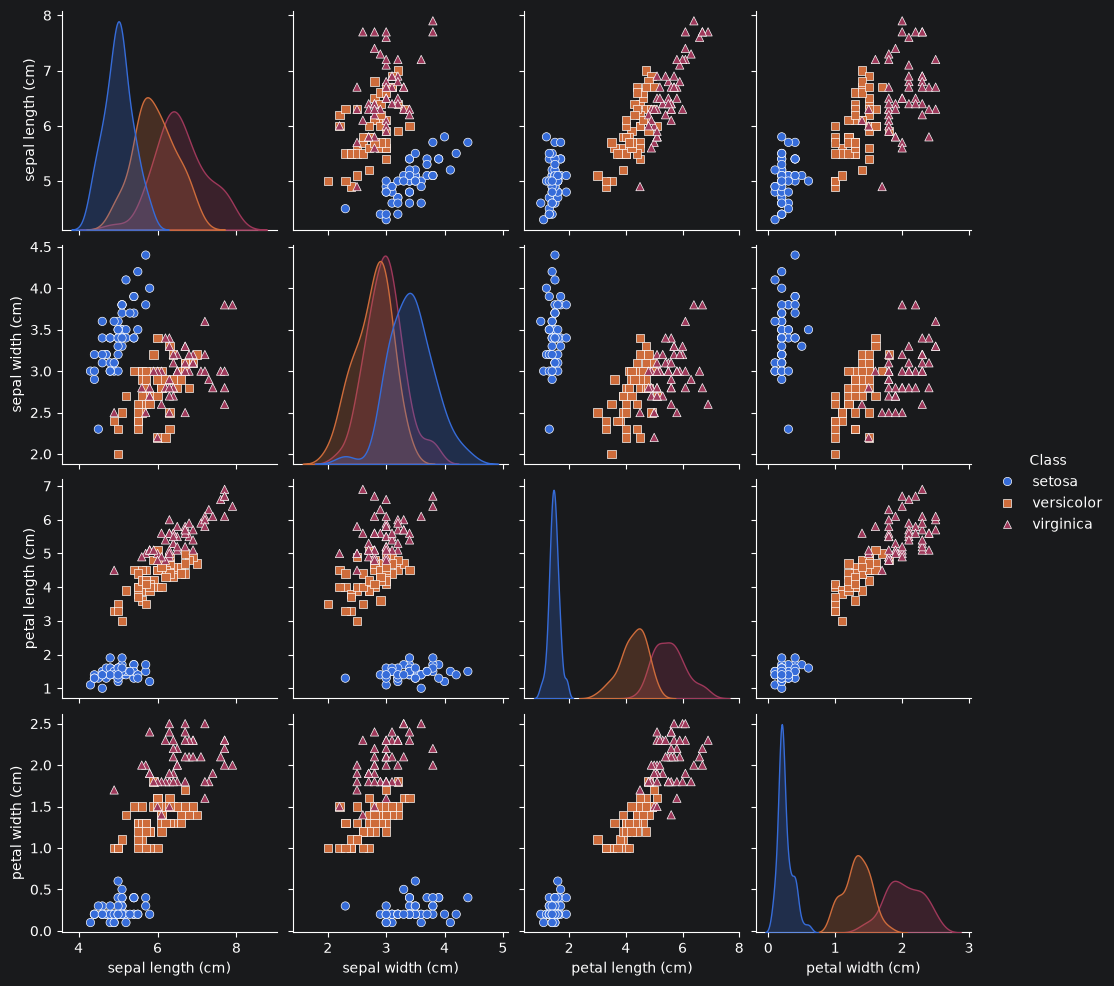

In [121]:
import seaborn as sns
# Plot pair plots with class colors
sns.pairplot(df, hue='Class', markers=['o', 's', '^'])
plt.show()

In [122]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_full, Y_full, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape  )
print(X_test.shape,  y_test.shape )

(120, 4) (120,)
(30, 4) (30,)


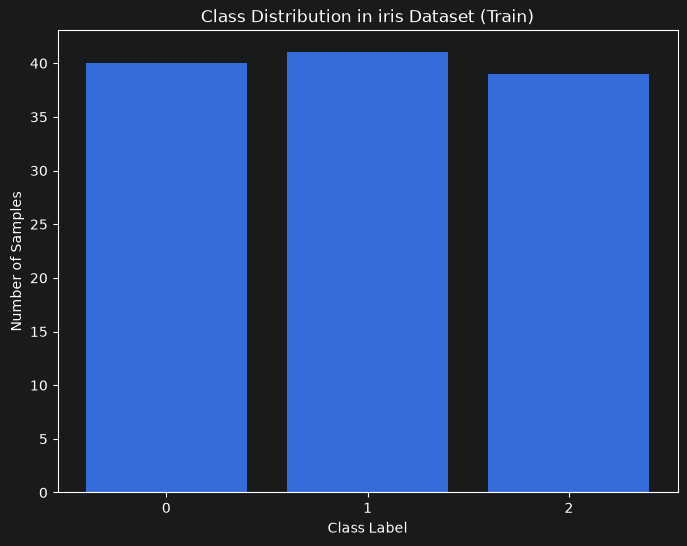

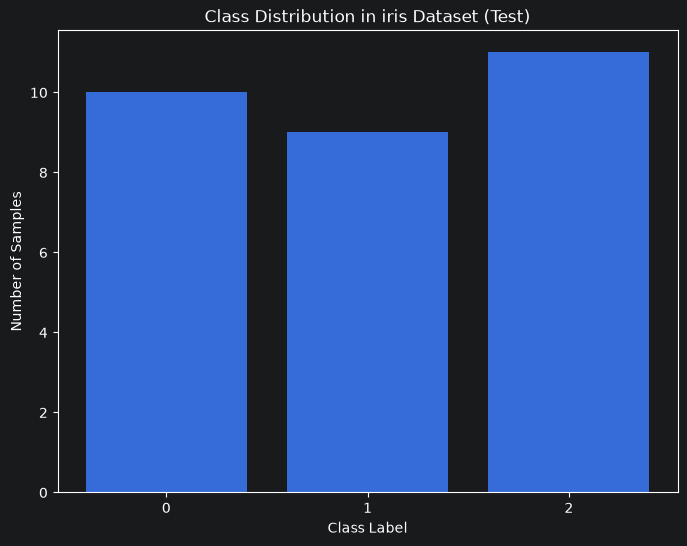

In [123]:
# Count the occurrences of each class label
class_counts_train = np.bincount(y_train)

# Generate class labels from 0 to 2
class_labels = np.arange(3)

# Plot the class distribution
plt.figure(figsize=(8, 6))
plt.bar(class_labels, class_counts_train, tick_label=class_labels, align='center')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in iris Dataset (Train)')
plt.show()

# Count the occurrences of each class label
class_counts_test = np.bincount(y_test)

# Generate class labels from 0 to 2
class_labels = np.arange(3)

# Plot the class distribution
plt.figure(figsize=(8, 6))
plt.bar(class_labels, class_counts_test, tick_label=class_labels, align='center')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in iris Dataset (Test)')
plt.show()

In [124]:
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(y_train.shape, y_test.shape  )


# One-hot encode the target labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape, y_test_cat.shape)

(120,) (30,)
(120, 3) (30, 3)


In [125]:
print(y_train[1], y_train_cat[1])
print(y_train[99], y_train_cat[99])
print(y_train[101], y_train_cat[101])

0 [1. 0. 0.]
1 [0. 1. 0.]
2 [0. 0. 1.]


In [126]:
from keras.activations import relu, softmax
from keras.models import Sequential
from keras.layers import Dense, Input

# Build the neural network model
model = Sequential()
model.add(Input(shape=(4,)))  # Input layer with 4 features
model.add(Dense(10, activation='relu')) # Hidden layer with 10 neurons and ReLU activation
model.add(Dense(3, activation='softmax'))# since we have three clases output size is  3

# Visualize the model architecture
# Print the model summary
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

In [127]:
from keras.optimizers import Adam

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2778 - loss: 1.3876 - val_accuracy: 0.5000 - val_loss: 1.0228
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3056 - loss: 1.2964 - val_accuracy: 0.5833 - val_loss: 0.9770
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3148 - loss: 1.2072 - val_accuracy: 0.6667 - val_loss: 0.9347
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3519 - loss: 1.1337 - val_accuracy: 0.6667 - val_loss: 0.8947
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4074 - loss: 1.0621 - val_accuracy: 0.6667 - val_loss: 0.8563
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4537 - loss: 0.9981 - val_accuracy: 0.7500 - val_loss: 0.8195
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5185 - loss: 0.9382 - val_accuracy: 0.7500 - val_loss: 0.7848
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5833 - loss: 0.8839 - val_accuracy: 0.8333 - 

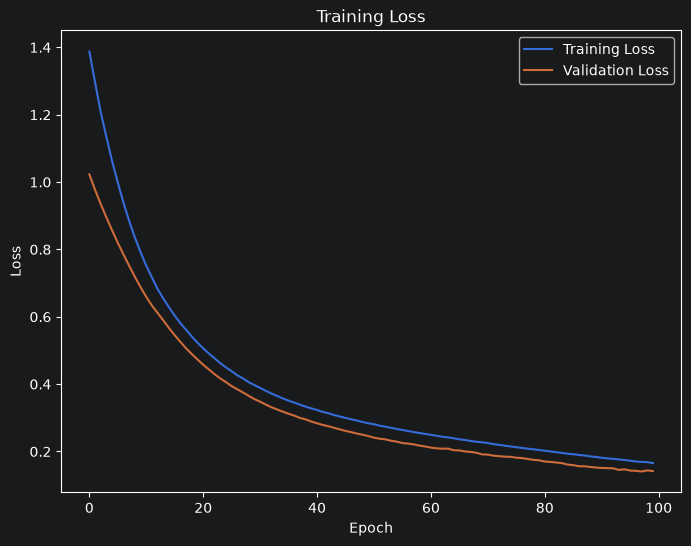

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.1181
Test loss: 0.1181, Test accuracy: 1.0000


In [128]:
learning_rate = 0.001
# Example learning rate
# Create an Adam optimizer with the specified learning rate
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model and store the training history
history = model.fit(X_train, y_train_cat, epochs=100, batch_size=8, validation_split=0.1)

# Plot training loss and accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()



# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}")

In [129]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to predicted class
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded true labels back to class numbers
y_true = np.argmax(y_test_cat, axis=1)

# Classification report
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



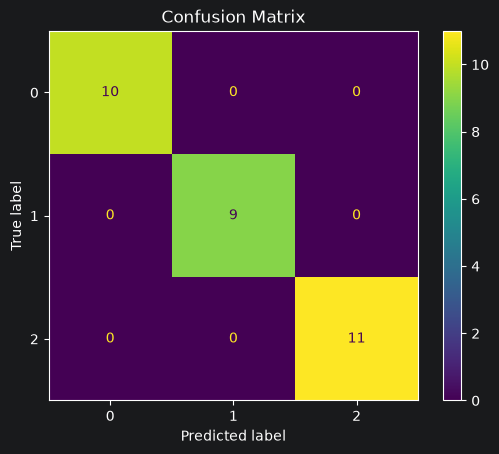

In [130]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()